Data directory: /home/mc06/Documents/CamCAN/code/camcan_meglongrest_specparamlme_2026/data


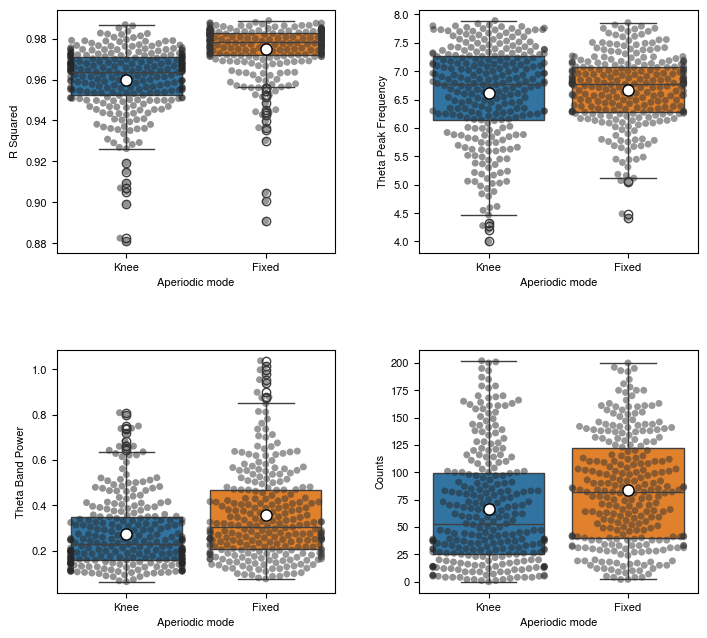

In [1]:
"""
Script to plot ans save Supplementary Figure 04.
"""

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

datadir = os.path.abspath(os.path.join(os.path.dirname( os.getcwd() ), '.', 'data'))
print(f'Data directory: {datadir}')

parameters = ['r_squared', 'theta_peak_freq', 'theta_band_power'] 
megtype = 'grad'

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Nimbus Sans"]
plt.rcParams['font.size'] = 8

fig, axs = plt.subplots(2, 2, figsize=(7.2, 7.2), gridspec_kw={'wspace': 0.3, 'hspace': 0.4, 'left':0.11, 'right':1, 'top':0.94, 'bottom':0.13})

for p, parameter in enumerate(parameters):

    ax_col = p%2
    ax_row = p//2

    df_plot = pd.read_csv(os.path.join(datadir, f'supp_figure04_{parameter}_source_data.csv'))

    sns.boxplot(data=df_plot, x='Aperiodic_mode', hue='Aperiodic_mode', y=parameter, ax=axs[ax_row, ax_col], showmeans=True, meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 8})
    sns.swarmplot(data=df_plot, x='Aperiodic_mode', hue='Aperiodic_mode', y=parameter, ax=axs[ax_row, ax_col], color='.2', alpha=0.5, zorder=2)

    axs[ax_row, ax_col].set_ylabel(parameter.replace('_', ' ').replace('freq', 'frequency').title())
    axs[ax_row, ax_col].set_xlabel('Aperiodic mode')

    if p==2:
        sns.boxplot(data=df_plot, x='Aperiodic_mode', hue='Aperiodic_mode', y='Counts', ax=axs[ax_row, ax_col+1], showmeans=True, meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 8})

        sns.swarmplot(data=df_plot, x='Aperiodic_mode', hue='Aperiodic_mode', y='Counts', ax=axs[ax_row, ax_col+1], color='.2', alpha=0.5, zorder=2)

        axs[ax_row, ax_col+1].set_xlabel('Aperiodic mode')


plt.savefig(f'Supp_Figure04.png', dpi=300, format='png', transparent=False)
plt.show()